## Zero Shot GeoCIR using GeoCLIP

In [1]:
import sys

sys.path.append("..")
from transformers import AutoTokenizer, AutoModel, AutoProcessor
import polars as pl
import os
import torch
from src.utils import read_index
from PIL import Image
import faiss
import numpy as np
import random
import matplotlib.pyplot as plt
from src.geoclip import GeoCLIP

device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model_name = "openai/clip-vit-large-patch14"
base_img_path = "../../datasets/google-landmark/index-img"
topk = 100

In [2]:
# style layer
clip_model = AutoModel.from_pretrained(clip_model_name).to(device)

# geo layer
geoclip = GeoCLIP().to(device)
geoclip_processor = geoclip.image_encoder.image_processor
geoclip_tokenizer = geoclip.text_encoder.tokenizer

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [3]:
clip_index, clip_meta = read_index("../index/clip_gld")
clip_index.hnsw.efSearch = 128

index, meta = read_index("../index/geoclip_gld")
index.hnsw.efSearch = 128

In [4]:
df_ref = pl.read_csv(
    # "../../datasets/mp16-reason/mp16-reason-train-annot-filtered.csv"
    "../../datasets/google-landmark/index_ref.csv"
)
df_test = pl.read_csv("../../datasets/google-landmark/index_test.csv")
df_test.tail()

landmark_id,input_url,resolved_url,geohack_url,latitude,longitude,error,supercategory,hierarchical_label,natural_or_human_made,rg_name,rg_admin1,rg_admin2,country_code,country,continent,subregion,id
i64,str,str,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str
35765,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",38.8823,-77.0572,null,"""river island""","""island""","""natural""","""Washington, D.C.""","""Washington, D.C.""","""""","""US""","""United States""","""Americas""","""Northern America""","""38f98b73bd62e36e"""
101098,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",40.6745,-73.9439,null,"""children's museum""","""museum""","""human-made""","""Brooklyn""","""New York""","""Kings County""","""US""","""United States""","""Americas""","""Northern America""","""6f6c87dd389e5be9"""
14347,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",33.6059,-117.918,null,"""single-family detached home""","""house""","""human-made""","""Newport Beach""","""California""","""Orange County""","""US""","""United States""","""Americas""","""Northern America""","""88111877b1da81d5"""
70309,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",21.010712,105.754249,null,"""military museum""","""museum""","""human-made""","""Cau Dien""","""Ha Noi""","""""","""VN""","""Vietnam""","""Asia""","""Southeast Asia""","""ae249f2c4821d3f3"""
84065,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",59.818278,18.652472,null,"""church building""","""church""","""human-made""","""Norrtalje""","""Stockholm""","""Norrtalje Kommun""","""SE""","""Sweden""","""Europe""","""Northern Europe""","""3602e10f76eccfd1"""


{'landmark_id': 97737, 'input_url': 'http://commons.wikimedia.org/wiki/Category:Kobe_Port_Tower', 'resolved_url': 'https://commons.wikimedia.org/wiki/Category:Kobe_Port_Tower', 'geohack_url': 'https://geohack.toolforge.org/geohack.php?pagename=Category:Kobe_Port_Tower&params=34.6825_N_135.18666666667_E_globe:Earth_&language=en', 'latitude': 34.6825, 'longitude': 135.18666666667, 'error': None, 'supercategory': 'observation tower', 'hierarchical_label': 'tower', 'natural_or_human_made': 'human-made', 'rg_name': 'Kobe', 'rg_admin1': 'Hyogo', 'rg_admin2': '', 'country_code': 'JP', 'country': 'Japan', 'continent': 'Asia', 'subregion': 'East Asia', 'id': '02c5ed624ea681fe'}


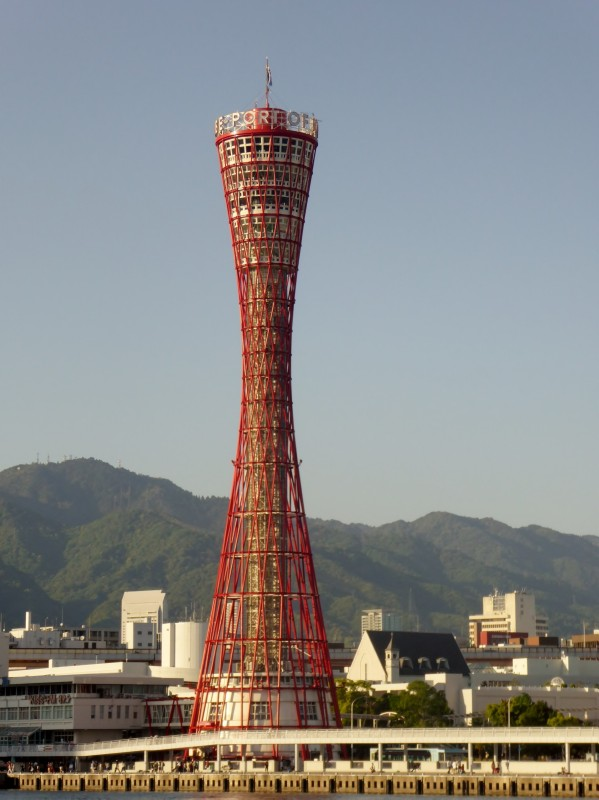

In [ ]:
japan_landmark = df_test.filter(pl.col("id") == "3be914f8c21669ec").to_dicts()
print(japan_landmark[0])
Image.open(os.path.join(base_img_path, f"{japan_landmark[0]['id']}.jpg"))

# japan_landmark = df_test.filter(pl.col("country_code") == "JP").to_dicts()
# rand_id = random.choice(range(len(japan_landmark)))
# plt.imshow(Image.open(os.path.join(base_img_path, f"{japan_landmark[rand_id]['id']}.jpg")))
# plt.title(f"{japan_landmark[rand_id]["supercategory"]}, {japan_landmark[rand_id]["country"]}")
# plt.show()

In [117]:
# japan_landmark[rand_id]
japan_landmark

[{'landmark_id': 97737,
  'input_url': 'http://commons.wikimedia.org/wiki/Category:Kobe_Port_Tower',
  'resolved_url': 'https://commons.wikimedia.org/wiki/Category:Kobe_Port_Tower',
  'geohack_url': 'https://geohack.toolforge.org/geohack.php?pagename=Category:Kobe_Port_Tower&params=34.6825_N_135.18666666667_E_globe:Earth_&language=en',
  'latitude': 34.6825,
  'longitude': 135.18666666667,
  'error': None,
  'supercategory': 'observation tower',
  'hierarchical_label': 'tower',
  'natural_or_human_made': 'human-made',
  'rg_name': 'Kobe',
  'rg_admin1': 'Hyogo',
  'rg_admin2': '',
  'country_code': 'JP',
  'country': 'Japan',
  'continent': 'Asia',
  'subregion': 'East Asia',
  'id': '02c5ed624ea681fe'}]

In [136]:
img_query = Image.open(os.path.join(base_img_path, japan_landmark[0]["id"] + ".jpg"))
img_processed = geoclip_processor(img_query, return_tensors="pt")
text_query = "a landmark located in Europe"
text_processed = geoclip_tokenizer(
    text_query,
    padding="max_length",
    truncation=True,
    max_length=77,
    return_tensors="pt",
)

with torch.no_grad():
    style_emb = geoclip.image_encoder(img_processed["pixel_values"].to(device)).cpu().numpy()
    geo_emb = geoclip.text_encoder(**{k: v.to(device) for k, v in text_processed.items()}).cpu().numpy()

alpha = 0.7
composed = (1 - alpha) * style_emb + alpha * geo_emb
faiss.normalize_L2(composed)

In [137]:
sim, ind = index.search(composed, topk)
ind = ind.reshape(-1)

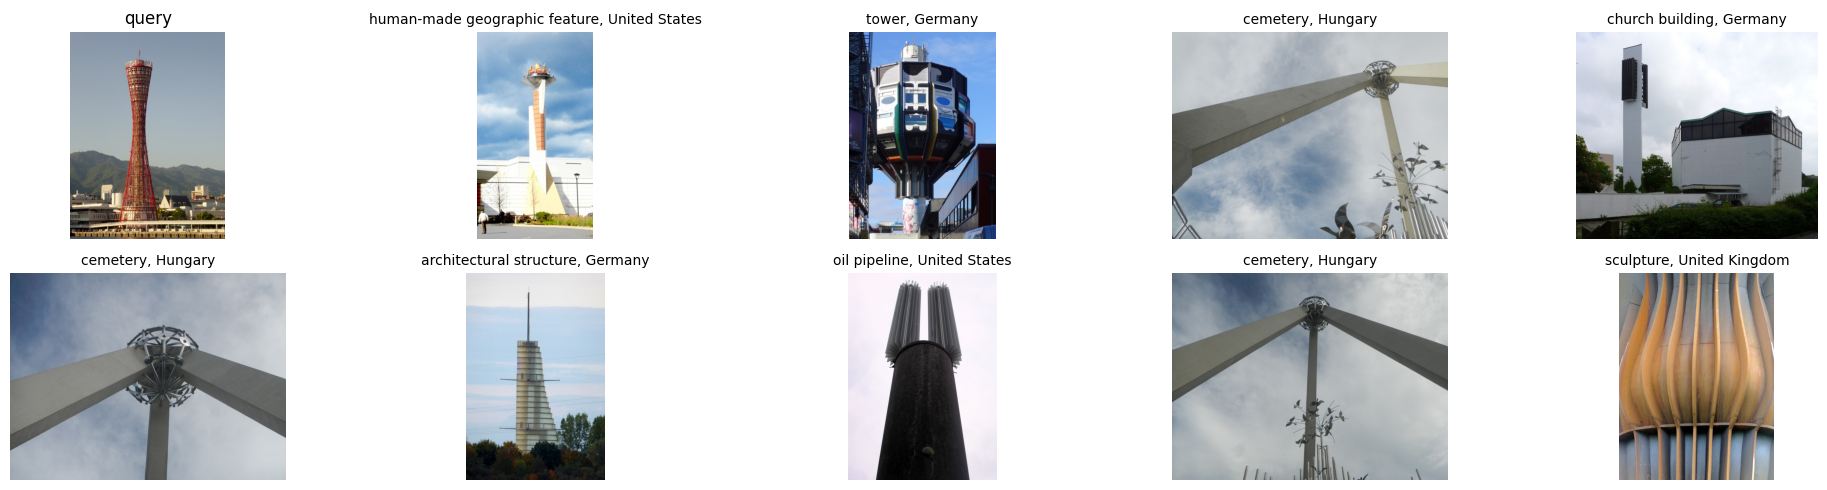

In [138]:
import os
from PIL import Image
import matplotlib.pyplot as plt

items = df_ref[ind[:10]].to_dicts()

fig, axes = plt.subplots(2, 5, figsize=(20, 5))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i == 0:
        ax.imshow(img_query)
        ax.set_title("query")
    else:
        img_path = os.path.join(base_img_path, items[i]["id"] + ".jpg")
        ax.imshow(Image.open(img_path))
        ax.set_title(f"{items[i]['supercategory']}, {items[i]['country']}", fontsize=10)
    ax.axis("off")

# hide any unused axes (safe if <10 items)
for ax in axes[len(items):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


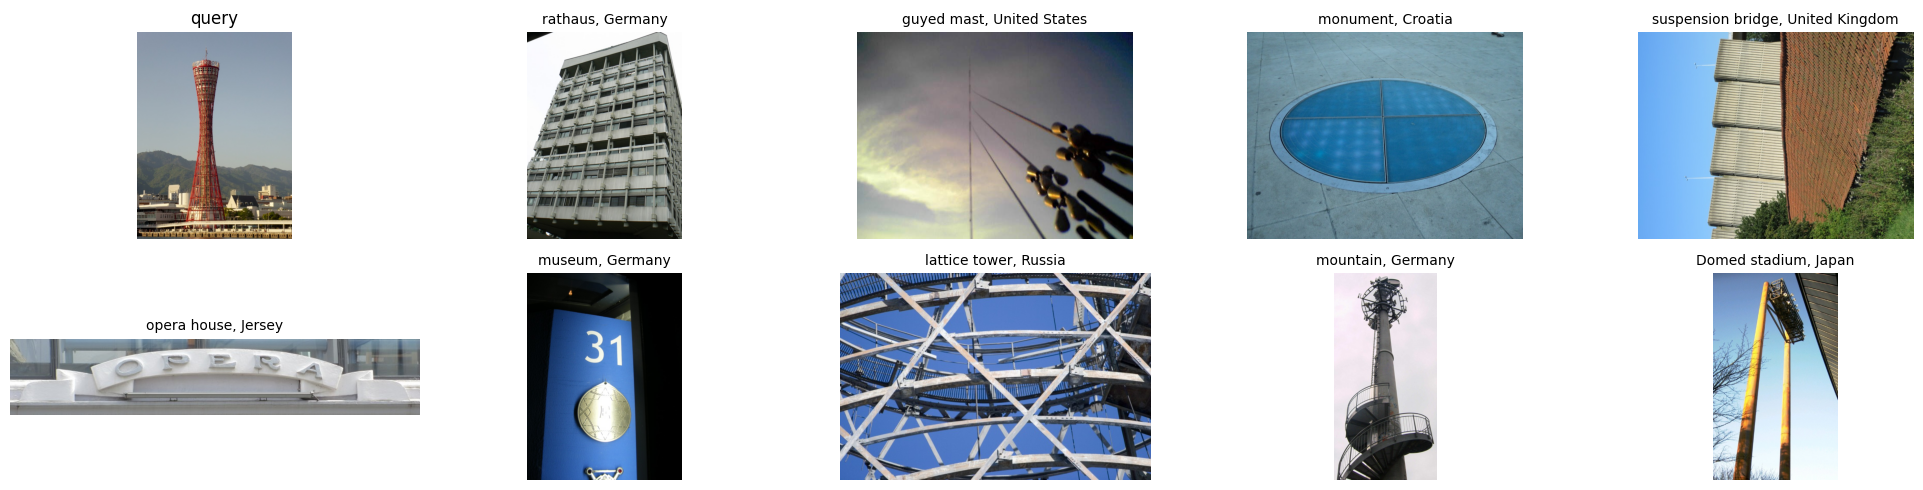

In [143]:
items = df_ref[ind[-10:]].to_dicts()

fig, axes = plt.subplots(2, 5, figsize=(20, 5))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i == 0:
        ax.imshow(img_query)
        ax.set_title("query")
    else:
        img_path = os.path.join(base_img_path, items[i]["id"] + ".jpg")
        ax.imshow(Image.open(img_path))
        ax.set_title(f"{items[i]['supercategory']}, {items[i]['country']}", fontsize=10)
    ax.axis("off")

# hide any unused axes (safe if <10 items)
for ax in axes[len(items):]:
    ax.axis("off")

plt.tight_layout()
plt.show()
